# Exploración SST Chile
Notebook ad-hoc usando datos de `data/runs/`.

## Celda 0 — Setup

In [1]:
from pathlib import Path
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from config import DATA_DIR, FIGURES_DIR, REGIONES, FECHA_FIN, RUN_ID
print("RUN_ID:", RUN_ID, "| FECHA_FIN:", FECHA_FIN)

RUN_ID: 2026-05 | FECHA_FIN: 2026-04-30


## Celda 1 — Selección de run
Elige automáticamente el run más reciente.

In [2]:
runs_disponibles = sorted(Path("data/runs/").iterdir())
run_a_explorar = runs_disponibles[-1]
print("Run seleccionado:", run_a_explorar)

Run seleccionado: data/runs/2026-05


## Celda 2 — Inspección del NetCDF

In [3]:
datasets = {}
for nombre in REGIONES:
    ruta = run_a_explorar / f"{nombre}_sst.nc"
    if ruta.exists():
        ds = xr.open_dataset(ruta)
        sst_c = ds["analysed_sst"] - 273.15
        print(f"=== {nombre} ===")
        print("Dimensiones:", dict(ds.dims))
        print("Rango fechas:", str(ds.time.min().values)[:10], "→", str(ds.time.max().values)[:10])
        print(f"SST min/mean/max: {float(sst_c.min()):.2f} / {float(sst_c.mean()):.2f} / {float(sst_c.max()):.2f} °C")
        print(f"NaN total: {int(sst_c.isnull().sum())}")
        print()
        datasets[nombre] = ds

=== los_lagos ===
Dimensiones: {'time': 731, 'latitude': 77, 'longitude': 65}
Rango fechas: 2023-01-01 → 2024-12-31
SST min/mean/max: 8.23 / 11.79 / 19.19 °C
NaN total: 1998554

=== aysen ===
Dimensiones: {'time': 731, 'latitude': 112, 'longitude': 88}
Rango fechas: 2023-01-01 → 2024-12-31
SST min/mean/max: 2.31 / 10.60 / 17.63 °C
NaN total: 4632347

=== magallanes ===
Dimensiones: {'time': 731, 'latitude': 158, 'longitude': 113}
Rango fechas: 2023-01-01 → 2024-12-31


/var/folders/7p/504w7r4d0_jgpsklf6wvnlc00000gn/T/ipykernel_79578/3787611133.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dimensiones:", dict(ds.dims))
/var/folders/7p/504w7r4d0_jgpsklf6wvnlc00000gn/T/ipykernel_79578/3787611133.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print("Dimensiones:", dict(ds.dims))
/var/folders/7p/504w7r4d0_jgpsklf6wvnlc00000gn/T/ipykernel_79578/3787611133.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping

SST min/mean/max: 0.37 / 7.09 / 13.88 °C
NaN total: 5570951



## Celda 3 — Visualización rápida (serie temporal)

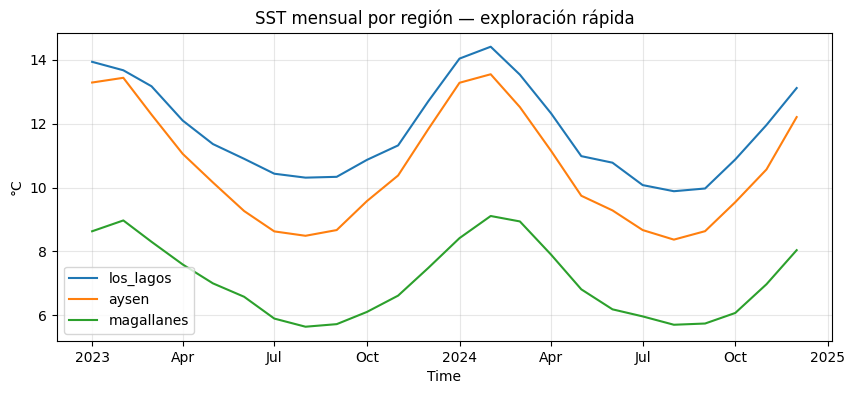

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
for nombre, ds in datasets.items():
    serie = (ds["analysed_sst"] - 273.15).mean(dim=["latitude", "longitude"])
    serie.resample(time="1MS").mean().plot(ax=ax, label=nombre)
ax.set_title("SST mensual por región — exploración rápida")
ax.set_ylabel("°C")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Celda 4 — Exploración de anomalías
Climatología baseline 1993–2010.

In [5]:
anomalias = {}
for nombre, ds in datasets.items():
    serie_mensual = (ds["analysed_sst"] - 273.15).mean(dim=["latitude", "longitude"]).resample(time="1MS").mean()
    df = serie_mensual.to_dataframe(name="sst").reset_index()
    df["mes"] = df["time"].dt.month
    baseline = df[df["time"].dt.year.between(1993, 2010)].groupby("mes")["sst"].mean()
    df["anomalia"] = df.apply(lambda r: r["sst"] - baseline.get(r["mes"], float("nan")), axis=1)
    anomalias[nombre] = df
    extremos = df[df["anomalia"].abs() > 2]
    print(f"{nombre}: {len(extremos)} meses con |anomalía| > 2°C")
    if not extremos.empty:
        print(extremos[["time", "sst", "anomalia"]].to_string(index=False))

los_lagos: 0 meses con |anomalía| > 2°C
aysen: 0 meses con |anomalía| > 2°C
magallanes: 0 meses con |anomalía| > 2°C


## Celda 5 — Sandbox libre

In [ ]:
# Espacio libre para exploración ad-hoc